<style>
    body, p, h1, h2, h3, li, span, div {
        font-family: 'Times New Roman', Times, serif !important;
    }
    ul ul, li li {
        list-style-type: none !important;
    }
    ul ul li::before, li li::before {
        content: "- " !important;
        display: inline-block;
        width: 1.2em;
        margin-left: -1.2em;
    }
    pre, code, .jp-OutputArea-output {
        font-family: Consolas, "Courier New", monospace !important;
    }
</style>

<br>

<div style="text-align: center;">
    <span style="font-size: 24px;">3_1_4_var_cuantitativas</span><br><br>
    <span>Julio 13, 2026</span><br><br><br>
    <img src="img/logoitqv1.jpg" width="450">
</div>

## 0.1 01PAO26-26 - Variables cuanitativas


<div style="text-align: center;">
    <img src="img/python_logo.png" width="500">
</div>

*Christian Villegas*

Link del repositorio: https://github.com/christian7villegas/Introducci-nPython

In [2]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)


[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [4]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [5]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC
print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


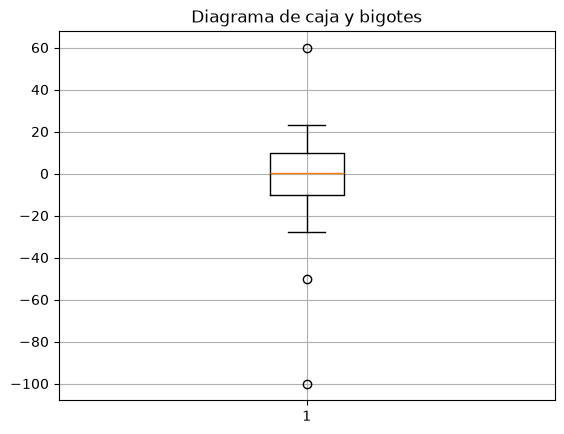

In [6]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [7]:
 # Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)


Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [9]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))
if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [11]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
pprint(iris)
X = iris.data
y = iris.target
# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???
# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
#???

{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

In [13]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la␣clase y representarlo en un gráfico (plt.errorbar)

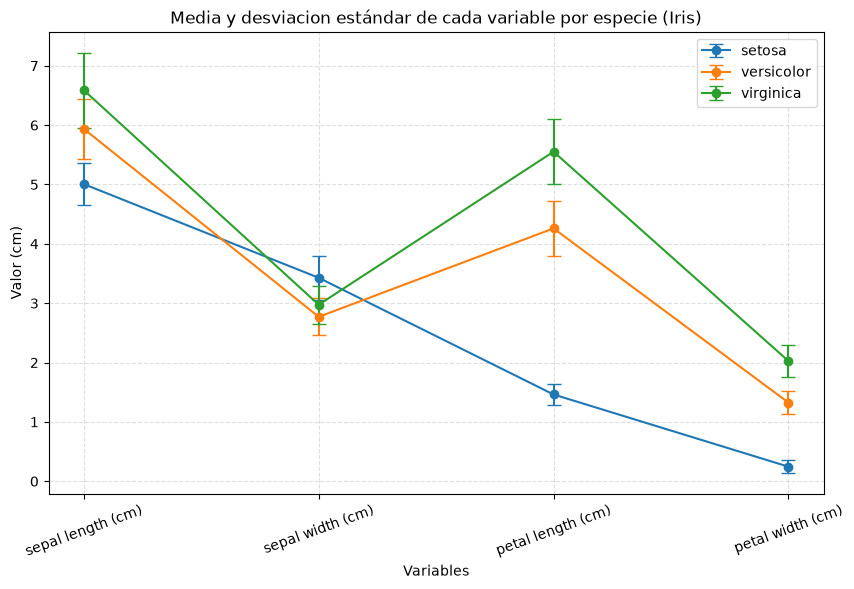

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
nombres_variables = iris.feature_names
nombres_especies = iris.target_names

# 2. Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# 3. Iteramos sobre cada una de las 3 especies (0: setosa, 1: versicolor, 2: virginica)
for i, especie in enumerate(nombres_especies):
    
    # Filtramos solo los datos que pertenecen a la especie actual
    datos_especie = X[y == i]
    
    # Calculamos la media y la desviación estándar por columna (axis=0)
    medias = np.mean(datos_especie, axis=0)
    desviaciones = np.std(datos_especie, axis=0)
    
    # 4. Dibujamos la línea con sus barras de error
    # fmt='-o' crea la línea con los puntos, y capsize le pone el "techo" a las barras
    plt.errorbar(nombres_variables, medias, yerr=desviaciones, 
                 fmt='-o', capsize=5, label=especie)

# 5. Damos formato al gráfico para que quede igual a la imagen de referencia
plt.title('Media y desviacion estándar de cada variable por especie (Iris)')
plt.xlabel('Variables')
plt.ylabel('Valor (cm)')

# Inclinamos los textos del eje X para que no se superpongan
plt.xticks(rotation=20) 

# Agregamos una cuadrícula suave de fondo
plt.grid(True, linestyle='--', alpha=0.4)

# Mostramos la leyenda y el gráfico final
plt.legend()
plt.show()